# Cell 1 _ Importing libararies

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

2026-06-25 19:35:33.069817: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782416133.311182      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782416133.382872      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782416133.921590      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782416133.921639      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782416133.921641      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# Cell 2 — Checking the dataset structure

In [2]:
print("Contents of /kaggle/input:")
print(os.listdir('/kaggle/input'))

Contents of /kaggle/input:
['datasets']


In [3]:
print("Inside datasets:")
print(os.listdir('/kaggle/input/datasets'))

Inside datasets:
['msambare']


In [4]:
print("Inside msambare:")
print(os.listdir('/kaggle/input/datasets/msambare'))

Inside msambare:
['fer2013']


In [5]:
print("Inside fer2013:")
print(os.listdir('/kaggle/input/datasets/msambare/fer2013'))


Inside fer2013:
['test', 'train']


In [6]:
train_path = '/kaggle/input/datasets/msambare/fer2013/train'
print("Classes in train:")
classes = os.listdir(train_path)
print(classes)

print("\nImage count per class:")
for cls in classes:
    count = len(os.listdir(os.path.join(train_path, cls)))
    print(f"  {cls}: {count} images")

Classes in train:
['surprise', 'fear', 'angry', 'neutral', 'sad', 'disgust', 'happy']

Image count per class:
  surprise: 3171 images
  fear: 4097 images
  angry: 3995 images
  neutral: 4965 images
  sad: 4830 images
  disgust: 436 images
  happy: 7215 images


# Cell 3_ Setting up paths and data generators

In [7]:
train_dir = '/kaggle/input/datasets/msambare/fer2013/train'
test_dir  = '/kaggle/input/datasets/msambare/fer2013/test'

IMG_SIZE = 48      # FER-2013's native resolution — no need to upscale
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.1   # carve out validation from train, since only train/test exist
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Class indices:", train_gen.class_indices)
print("Train batches:", len(train_gen))
print("Val batches:  ", len(val_gen))
print("Test batches: ", len(test_gen))

Found 25841 images belonging to 7 classes.
Found 2868 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.
Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Train batches: 404
Val batches:   45
Test batches:  113


In [8]:
train_dir = '/kaggle/input/datasets/msambare/fer2013/train'
test_dir  = '/kaggle/input/datasets/msambare/fer2013/test'

print("train_dir exists:", os.path.exists(train_dir))
print("test_dir exists: ", os.path.exists(test_dir))

train_dir exists: True
test_dir exists:  True


# Cell 4 _ Calculating class weights to fix the imbalance

In [12]:
from sklearn.utils.class_weight import compute_class_weight

# train_gen.classes gives the lebel of every single training image, in order 
class_labels = train_gen.classes

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_labels),
    y=class_labels
)

# Convert to the dict format keras expects: {0: weight, 1: weight,...}
class_weights = dict(enumerate(class_weights_array))


print("Class weghts:")
for idx, weight in class_weights.items():
    class_name = list(train_gen.class_indices.keys())[idx]
    print(f" {class_name} (class{idx}): {weight:.3f}")

Class weghts:
 angry (class0): 1.027
 disgust (class1): 9.393
 fear (class2): 1.001
 happy (class3): 0.568
 neutral (class4): 0.826
 sad (class5): 0.849
 surprise (class6): 1.293


# Cell 5 _ Building the model

In [14]:
model = Sequential([
    # Block 1
    Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(48, 48, 1)),
    BatchNormalization(),
    Conv2D(64,(3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 2
    Conv2D(128,(3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128,(3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 3
    Conv2D(256,(3,3), activation='relu',padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.3),

    # Classifier head
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(7, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


I0000 00:00:1782417770.724698      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782417770.730719      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,919,111 (11.14 MB)

 Trainable params: 2,917,319 (11.13 MB)

 Non-trainable params: 1,792 (7.00 KB)

# Cell 6 _ Training the model with class weights

In [18]:
callbacks = [
    EarlyStopping(patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
    ModelCheckpoint('/kaggle/working/best_emotion_model.h5', save_best_only=True, verbose=1)
]


history = model.fit(
        train_gen,
        epochs=40,
        validation_data=val_gen,
        callbacks=callbacks,
        class_weight=class_weights
    )


Epoch 1/40


I0000 00:00:1782418503.206787    1726 service.cc:152] XLA service 0x7cb7140023d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782418503.206837    1726 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782418503.206841    1726 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782418504.071967    1726 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/404 ━━━━━━━━━━━━━━━━━━━━ 1:32:50 14s/step - accuracy: 0.2031 - loss: 2.9487

I0000 00:00:1782418512.856565    1726 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.1736 - loss: 2.5241
Epoch 1: val_loss improved from None to 2.38929, saving model to /kaggle/working/best_emotion_model.h5


...


Epoch 26: finished saving model to /kaggle/working/best_emotion_model.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 35s 87ms/step - accuracy: 0.5844 - loss: 1.0515 - val_accuracy: 0.6046 - val_loss: 1.0834 - learning_rate: 2.5000e-04
Epoch 27/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5854 - loss: 1.0417
Epoch 27: val_loss did not improve from 1.08340
404/404 ━━━━━━━━━━━━━━━━━━━━ 35s 86ms/step - accuracy: 0.5885 - loss: 1.0435 - val_accuracy: 0.5861 - val_loss: 1.1057 - learning_rate: 2.5000e-04
Epoch 28/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5950 - loss: 1.0110
Epoch 28: val_loss improved from 1.08340 to 1.08140, saving model to /kaggle/working/best_emotion_model.h5



Epoch 28: finished saving model to /kaggle/working/best_emotion_model.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 35s 87ms/step - accuracy: 0.5928 - loss: 1.0257 - val_accuracy: 0.5924 - val_loss: 1.0814 - learning_rate: 2.5000e-04
Epoch 29/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.5969 - loss: 1.0124
Epoch 29: val_loss did not improve from 1.08140
404/404 ━━━━━━━━━━━━━━━━━━━━ 35s 87ms/step - accuracy: 0.5924 - loss: 1.0255 - val_accuracy: 0.5914 - val_loss: 1.0859 - learning_rate: 2.5000e-04
Epoch 30/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.6000 - loss: 1.0187
Epoch 30: val_loss did not improve from 1.08140
404/404 ━━━━━━━━━━━━━━━━━━━━ 35s 86ms/step - accuracy: 0.5965 - loss: 1.0264 - val_accuracy: 0.5983 - val_loss: 1.0861 - learning_rate: 2.5000e-04
Epoch 31/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.5892 - loss: 1.0306
Epoch 31: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 31: val_loss did not improve from 1.08140


Epoch 32: finished saving model to /kaggle/working/best_emotion_model.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 36s 88ms/step - accuracy: 0.6022 - loss: 1.0112 - val_accuracy: 0.5959 - val_loss: 1.0725 - learning_rate: 1.2500e-04
Epoch 33/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5975 - loss: 1.0011
Epoch 33: val_loss improved from 1.07255 to 1.06109, saving model to /kaggle/working/best_emotion_model.h5



Epoch 33: finished saving model to /kaggle/working/best_emotion_model.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 35s 86ms/step - accuracy: 0.6006 - loss: 0.9951 - val_accuracy: 0.5997 - val_loss: 1.0611 - learning_rate: 1.2500e-04
Epoch 34/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.5980 - loss: 0.9987
Epoch 34: val_loss did not improve from 1.06109
404/404 ━━━━━━━━━━━━━━━━━━━━ 35s 87ms/step - accuracy: 0.6032 - loss: 0.9904 - val_accuracy: 0.6074 - val_loss: 1.0666 - learning_rate: 1.2500e-04
Epoch 35/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6097 - loss: 0.9883
Epoch 35: val_loss improved from 1.06109 to 1.04491, saving model to /kaggle/working/best_emotion_model.h5



Epoch 35: finished saving model to /kaggle/working/best_emotion_model.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 36s 88ms/step - accuracy: 0.6052 - loss: 0.9906 - val_accuracy: 0.6098 - val_loss: 1.0449 - learning_rate: 1.2500e-04
Epoch 36/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6024 - loss: 0.9929
Epoch 36: val_loss did not improve from 1.04491
404/404 ━━━━━━━━━━━━━━━━━━━━ 35s 88ms/step - accuracy: 0.6052 - loss: 0.9808 - val_accuracy: 0.6043 - val_loss: 1.0487 - learning_rate: 1.2500e-04
Epoch 37/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.6053 - loss: 0.9861
Epoch 37: val_loss did not improve from 1.04491
404/404 ━━━━━━━━━━━━━━━━━━━━ 35s 87ms/step - accuracy: 0.6067 - loss: 0.9855 - val_accuracy: 0.5882 - val_loss: 1.1203 - learning_rate: 1.2500e-04
Epoch 38/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.6080 - loss: 0.9849
Epoch 38: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 38: val_loss did not improve from 1.04491


# Cell 7 _ Saving accuracy & loss plots

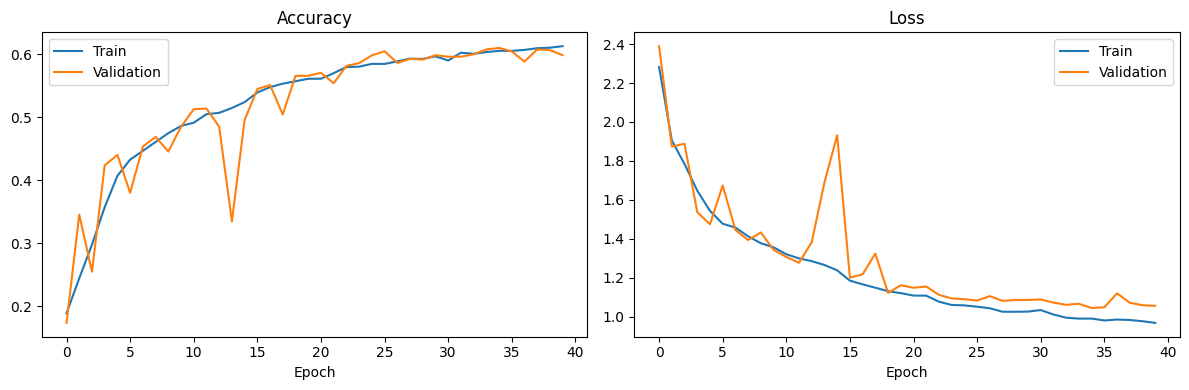

Plot saved!


In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('/kaggle/working/accuracy_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

# Cell 8 _ Evaluating on test set + confusion matrix

113/113 ━━━━━━━━━━━━━━━━━━━━ 34s 301ms/step - accuracy: 0.6272 - loss: 0.9927

Test accuracy: 62.72%
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step


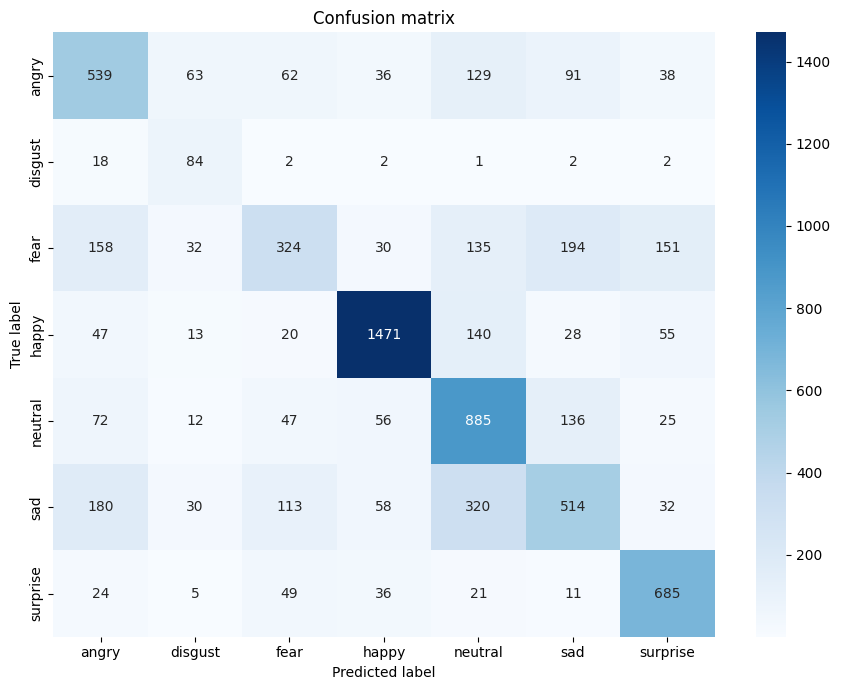


Classification report:
              precision    recall  f1-score   support

       angry       0.52      0.56      0.54       958
     disgust       0.35      0.76      0.48       111
        fear       0.53      0.32      0.39      1024
       happy       0.87      0.83      0.85      1774
     neutral       0.54      0.72      0.62      1233
         sad       0.53      0.41      0.46      1247
    surprise       0.69      0.82      0.75       831

    accuracy                           0.63      7178
   macro avg       0.58      0.63      0.59      7178
weighted avg       0.63      0.63      0.62      7178



In [20]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"\nTest accuracy: {test_acc*100:.2f}%")

y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

class_names = list(test_gen.class_indices.keys())

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# Cell 9 _ Saving the model

In [21]:
model.save('/kaggle/woriking/emotion_model.h5')

import json
class_names_list = list(train_gen.class_indices.keys())
with open('/kaggle/working/class_names.json', 'w') as f:
    json.dump(class_names_list, f)

print("Model and class names saved")
print("Classes:", class_names_list)

Model and class names saved
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
